In [52]:
# Cargamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_log_error



In [53]:
# Cargamos el dataset
drive.mount("/content/drive")

df = pd.read_csv("/content/drive/MyDrive/ML/train.csv")  # Modificar según ruta donde se almacene

print(df.head()) # Los datos cargaron correctamente

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllP

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [55]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


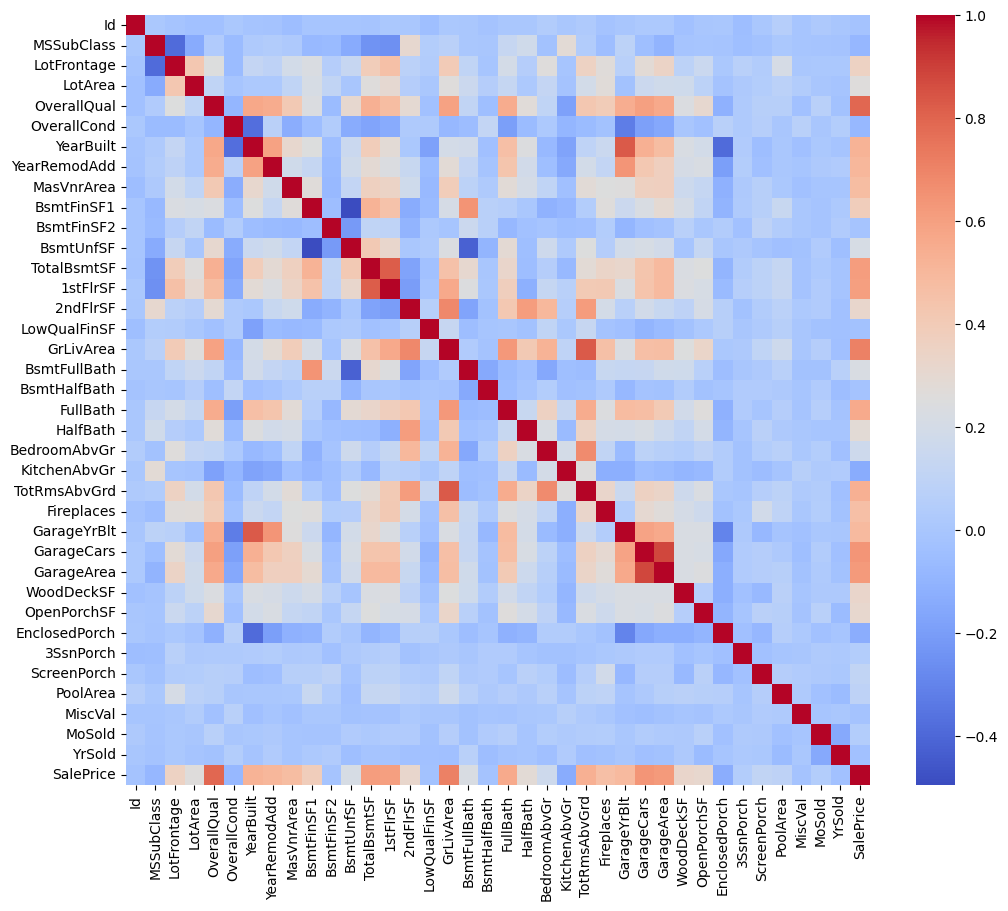

In [56]:
df_numeric = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,10))
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.show()

Observamos que en general hay poca correlación entre las variables, aunque en muchos otros casos, presentan correlacion elevada positiva o moderada negativa.

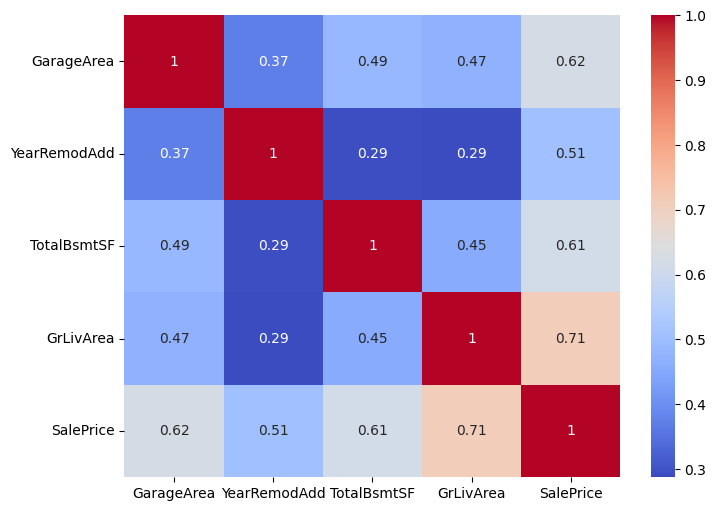

In [57]:
# Selecionamos las variables de interes.
features = ["GarageArea", "YearRemodAdd", "TotalBsmtSF", "GrLivArea"]
target = "SalePrice"

dfc = df_numeric[features + [target]].dropna()

# Graficar la correlación solo de estas variables
plt.figure(figsize=(8,6))
sns.heatmap(dfc.corr(), annot=True, cmap="coolwarm")
plt.show() # Comprobamos que, efectivamente, las variables están correlacionadas.

In [58]:
X = df2[["GarageArea", "YearRemodAdd", "TotalBsmtSF", "GrLivArea"]] # Selecionamos las variables

# Normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [59]:
# Aplicamos el PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.54838073 0.1901728 ]


Aproximadamente captura el 74% de la información. Un dato relativamente bueno.

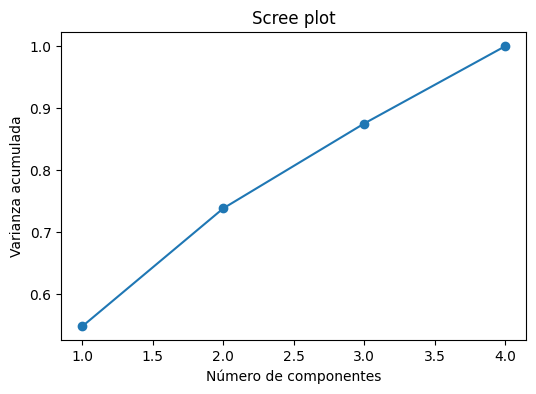

In [60]:
pca_full = PCA(n_components=4)  # probamos con
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3, 4], np.cumsum(pca_full.explained_variance_ratio_), 'o-')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Scree plot')
plt.show()

Nos quedamos con 2 componentes.

In [61]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"])

print(pca_components)

     GarageArea  YearRemodAdd  TotalBsmtSF  GrLivArea
PC1    0.542671      0.418537     0.518308   0.511558
PC2   -0.055849      0.883023    -0.324224  -0.334709


El primer componente principal (PC1) captura principalmente el tamaño total de la vivienda, ya que todas las variables presentan pesos positivos similares. El segundo componente (PC2) está dominado por el año de remodelación, reflejando una dimensión relacionada con la modernidad frente al tamaño. A partir de estos resultados, se crean nuevas variables que sintetizan estas relaciones para mejorar la modelización.

In [62]:
# Feature 1: tamaño total usable
df2["Feature1"] = df2["GrLivArea"] + df2["TotalBsmtSF"]

# Feature 2: sótano ponderado por renovación
df2["Feature2"] = df2["TotalBsmtSF"] * df2["YearRemodAdd"]
df2.head()

,GarageArea,YearRemodAdd,TotalBsmtSF,GrLivArea,SalePrice,Feature1,Feature2
0,548,2003,856,1710,208500,2566,1714568
1,460,1976,1262,1262,181500,2524,2493712
2,608,2002,920,1786,223500,2706,1841840
3,642,1970,756,1717,140000,2473,1489320
4,836,2000,1145,2198,250000,3343,2290000


In [63]:
# Separamos las variables y hacemos train-test.
X2 = df2[["GarageArea", "YearRemodAdd", "TotalBsmtSF", "GrLivArea", "Feature1", "Feature2"]]
y = df2["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

In [64]:
# Entrenamos el modelo

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [65]:
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
print("RMSLE:", rmsle)

RMSLE: 0.18842439473067474


In [66]:
# Modelo sin nuevas features

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y, test_size=0.2, random_state=42)
model_base = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model_base.fit(X_train_b, y_train_b)

y_pred_b = model_base.predict(X_test_b)
y_pred_b = np.maximum(y_pred_b, 0)

rmsle_base = np.sqrt(mean_squared_log_error(y_test_b, y_pred_b))
print("RMSLE:", rmsle_base)

RMSLE: 0.181640625


El modelo con las nuevas features no mejora el modelo base ya que Feature1 y Feature2 son combinaciones lineales de variables ya presentes,
por lo que XGBoost no extrae información adicional relevante.